In [11]:
# Environment setup
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/mac/Studying/OTTO/scenario_generator


In [12]:
# Run the pipeline on City Drive
from src.pipeline import Pipeline

pipeline = Pipeline(config_dir="../config")
result = pipeline.run(
    scenario_path="../config/scenarios/city_drive.yaml",
    output_dir="../data",
)

print(f"Scenario: {result.scenario.name}")
print(f"Vehicle:  {result.scenario.vehicle_id}")
print(f"Frames:   {result.n_frames}")
print(f"Timesteps:  {result.n_signal_rows}")
print()
print(f"Frames CSV:  {result.frames_path}")
print(f"Timesteps CSV: {result.signals_path}")

Scenario: City Drive
Vehicle:  sedan_a
Frames:   10200
Timesteps:  6000

Frames CSV:  ../data/sedan_a/city_drive.frames.csv
Timesteps CSV: ../data/sedan_a/city_drive.signals.csv


In [13]:
# Inspect the frames CSV
import pandas as pd

frames_df = pd.read_csv(result.frames_path)
print(f"Shape: {frames_df.shape}")
print(f"Columns: {list(frames_df.columns)}")
print()
print("First 15 frames:")
print(frames_df.head(15).to_string(index=False))

Shape: (10200, 3)
Columns: ['timestamp_ms', 'can_id', 'payload_hex']

First 15 frames:
 timestamp_ms can_id      payload_hex
            0  0x100 0c80003c00000000
            0  0x120 000003e800000000
            0  0x1A0 0000000000000000
           10  0x100 0c80003c00000000
           20  0x100 0c80003c00000000
           20  0x1A0 0000000000000000
           30  0x100 0c80003c00000000
           40  0x100 0c80003c00000000
           40  0x1A0 0000000000000000
           50  0x100 0c80003c00000000
           50  0x120 000003e800000000
           60  0x100 0c80003c00000000
           60  0x1A0 0000000000000000
           70  0x100 0c80003c00000000
           80  0x100 0c80003c00000000


In [14]:
# Inspect the signals CSV
signals_df = pd.read_csv(result.signals_path)
print(f"Shape: {signals_df.shape}")
print(f"Columns: {list(signals_df.columns)}")
print()
print("First 5 signal rows:")
print(signals_df.head(5).to_string(index=False))
print()
print("Statistics:")
print(signals_df.describe().round(2).to_string())

Shape: (6000, 10)
Columns: ['time_s', 'timestamp_ms', 'engine_rpm', 'throttle_position', 'coolant_temperature', 'brake_pressure', 'brake_pedal', 'wheel_speed', 'vehicle_speed', 'longitudinal_acceleration']

First 5 signal rows:
 time_s  timestamp_ms  engine_rpm  throttle_position  coolant_temperature  brake_pressure  brake_pedal  wheel_speed  vehicle_speed  longitudinal_acceleration
   0.00             0       800.0                0.0            20.000000             0.0          0.0          0.0            0.0                        0.0
   0.01            10       800.0                0.0            20.002333             0.0          0.0          0.0            0.0                        0.0
   0.02            20       800.0                0.0            20.004667             0.0          0.0          0.0            0.0                        0.0
   0.03            30       800.0                0.0            20.007000             0.0          0.0          0.0            0.0          

In [15]:
# Run the pipeline on Highway Cruise
result_hw = pipeline.run(
    scenario_path="../config/scenarios/highway_cruise.yaml",
    output_dir="../data",
)

print(f"Scenario: {result_hw.scenario.name}")
print(f"Vehicle:  {result_hw.scenario.vehicle_id}")
print(f"Frames:   {result_hw.n_frames}")
print(f"Timesteps:  {result_hw.n_signal_rows}")
print()
print(f"Frames CSV:  {result_hw.frames_path}")
print(f"Timesteps CSV: {result_hw.signals_path}")

Scenario: Highway Cruise
Vehicle:  suv_b
Frames:   15300
Timesteps:  9000

Frames CSV:  ../data/suv_b/highway_cruise.frames.csv
Timesteps CSV: ../data/suv_b/highway_cruise.signals.csv


In [17]:
# Cell 5 — Directory structure verification
from pathlib import Path

data_dir = Path("../data")
print("Generated data directory:")
for vehicle_dir in sorted(data_dir.iterdir()):
    if vehicle_dir.is_dir():
        print(f"  {vehicle_dir.name}/")
        for f in sorted(vehicle_dir.iterdir()):
            size_kb = f.stat().st_size / 1024
            print(f"    {f.name}  ({size_kb:.1f} KB)")

Generated data directory:
  sedan_a/
    city_drive.frames.csv  (297.0 KB)
    city_drive.signals.csv  (609.0 KB)
  suv_b/
    highway_cruise.frames.csv  (446.4 KB)
    highway_cruise.signals.csv  (1013.0 KB)


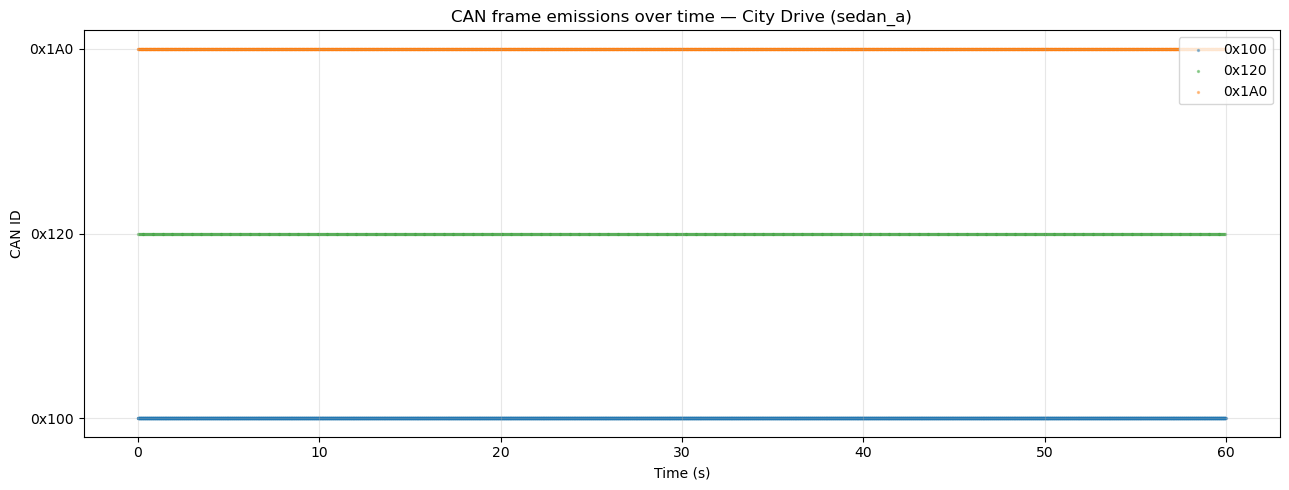

In [18]:
# Visualize the frames CSV as a CAN traffic timeline
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(13, 5))
can_ids = sorted(frames_df["can_id"].unique())
colors = {"0x100": "tab:blue", "0x1A0": "tab:orange", "0x120": "tab:green"}

for cid in can_ids:
    subset = frames_df[frames_df["can_id"] == cid]
    ax.scatter(
        subset["timestamp_ms"] / 1000,
        [cid] * len(subset),
        s=2,
        alpha=0.4,
        color=colors.get(cid, "gray"),
        label=cid,
    )

ax.set_xlabel("Time (s)")
ax.set_ylabel("CAN ID")
ax.set_title("CAN frame emissions over time — City Drive (sedan_a)")
ax.legend(loc="upper right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

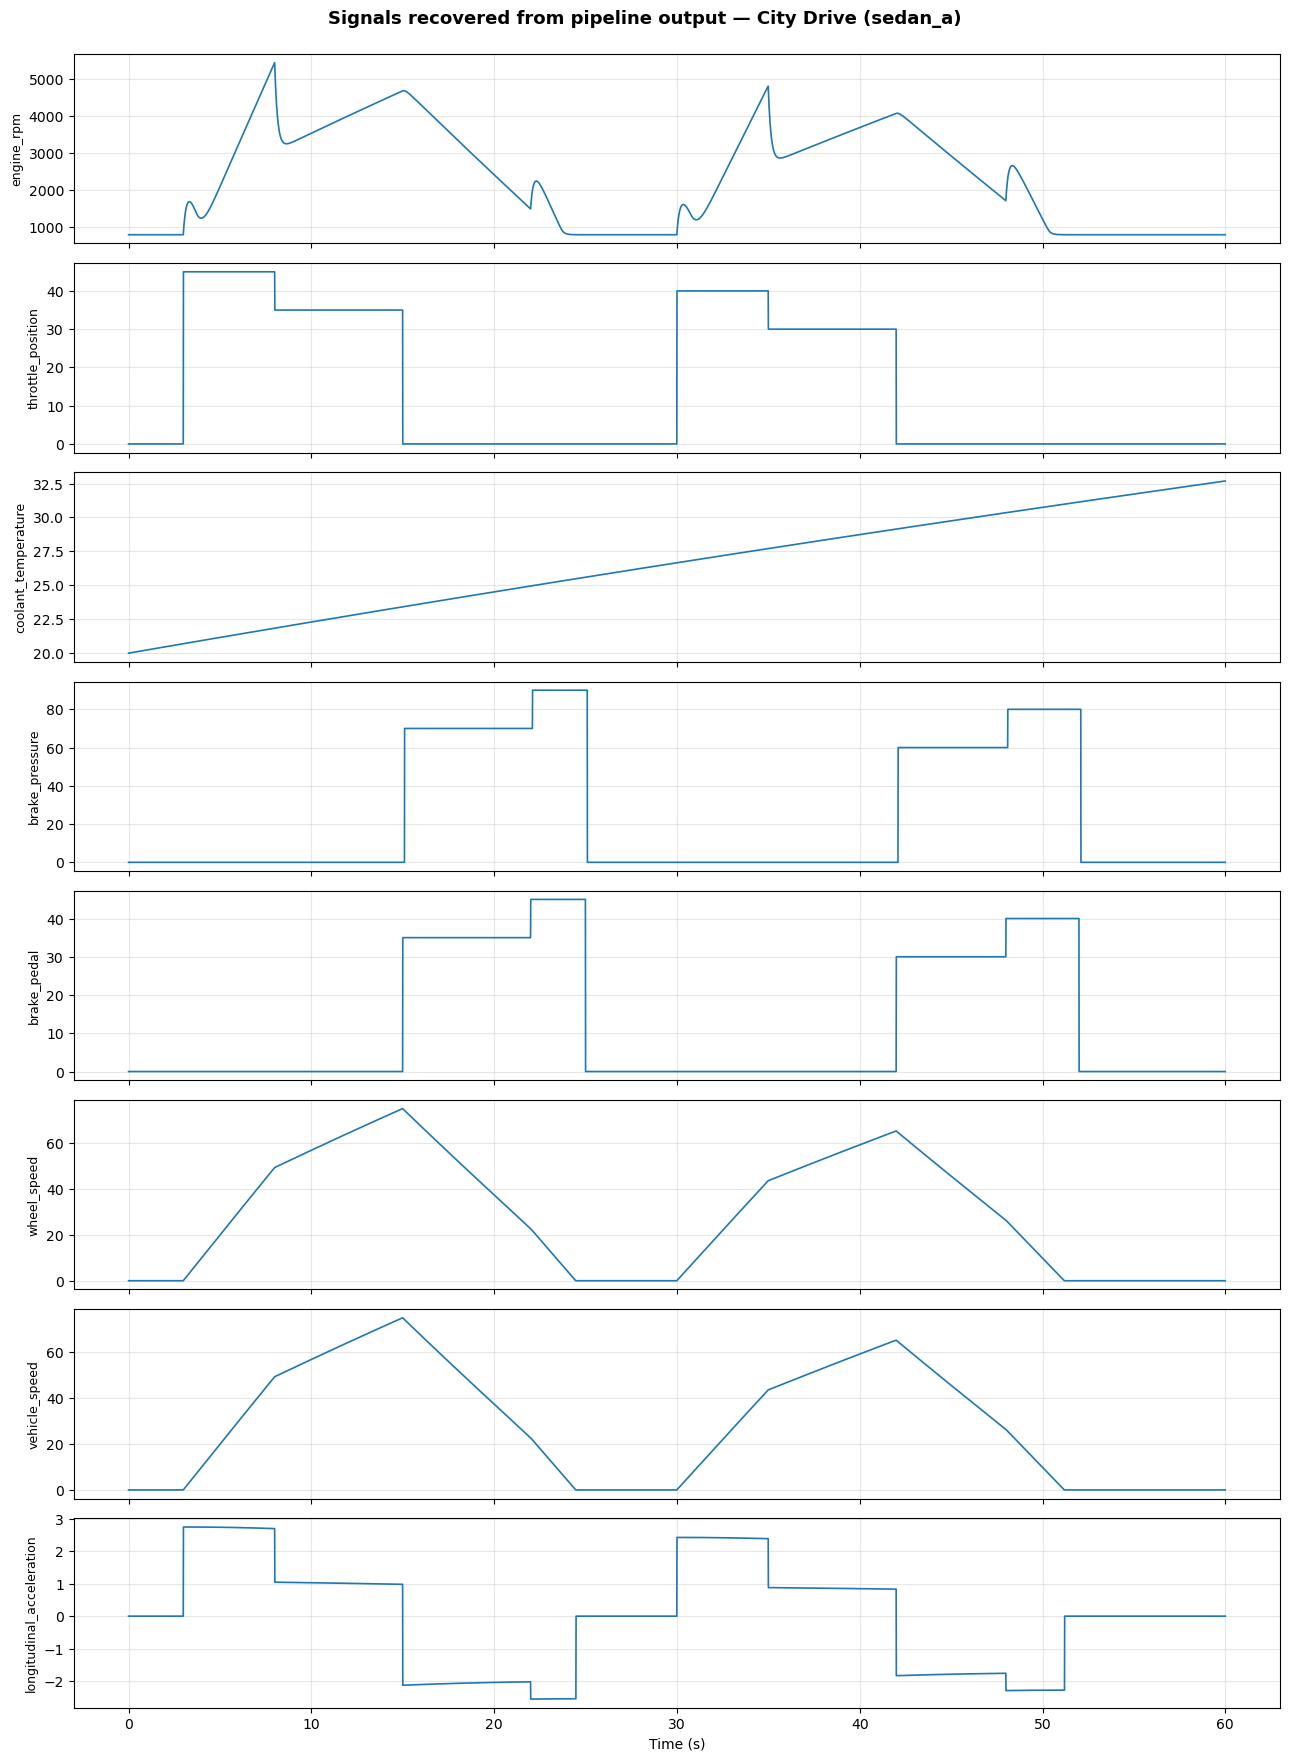

In [19]:
#  Visualize all signals from the signals CSV
import matplotlib.pyplot as plt

signals_to_plot = [
    "engine_rpm", "throttle_position", "coolant_temperature",
    "brake_pressure", "brake_pedal", "wheel_speed",
    "vehicle_speed", "longitudinal_acceleration",
]

fig, axes = plt.subplots(len(signals_to_plot), 1, figsize=(13, 2.2 * len(signals_to_plot)), sharex=True)
for ax, sig in zip(axes, signals_to_plot):
    ax.plot(signals_df["time_s"], signals_df[sig], linewidth=1.2)
    ax.set_ylabel(sig, fontsize=9)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Time (s)")
fig.suptitle("Signals recovered from pipeline output — City Drive (sedan_a)",
             fontsize=13, fontweight="bold", y=0.998)
plt.tight_layout()
plt.show()

In [20]:
# Round-trip verification summary
from src.can_encoder import CANEncoder

vehicle = pipeline.vehicles["sedan_a"]
encoder = CANEncoder(vehicle, pipeline.signals_cfg)

# Pick a row where the vehicle is actively moving
target_ts = 40000  # t=40 s
frames_at_target = frames_df[frames_df["timestamp_ms"] == target_ts]

decoded = {}
for _, row in frames_at_target.iterrows():
    can_id = int(row["can_id"], 16)
    payload = bytes.fromhex(row["payload_hex"])
    decoded.update(encoder.decode(can_id, payload))

signals_row = signals_df[signals_df["timestamp_ms"] == target_ts].iloc[0]

print(f"Round-trip check at t={target_ts} ms")
print(f"{'Signal':30s}  {'Decoded':>12s}  {'Signals CSV':>12s}  {'Diff':>10s}")
print("-" * 70)
for sig in sorted(decoded.keys()):
    d = decoded[sig]
    s = signals_row[sig]
    print(f"{sig:30s}  {d:12.3f}  {s:12.3f}  {abs(d-s):10.3f}")

Round-trip check at t=40000 ms
Signal                               Decoded   Signals CSV        Diff
----------------------------------------------------------------------
brake_pedal                            0.000         0.000       0.000
brake_pressure                         0.000         0.000       0.000
coolant_temperature                   29.000        28.738       0.262
engine_rpm                          3684.750      3684.709       0.041
longitudinal_acceleration              0.850         0.847       0.003
throttle_position                     30.000        30.000       0.000
vehicle_speed                         59.050        59.046       0.004
wheel_speed                           59.050        59.046       0.004


In [21]:
signals_df = pd.read_csv("../data/sedan_a/city_drive.signals.csv")
row = signals_df.iloc[5674]
print(row)

time_s                          56.74000
timestamp_ms                 56740.00000
engine_rpm                     800.00000
throttle_position                0.00000
coolant_temperature             32.06267
brake_pressure                   0.00000
brake_pedal                      0.00000
wheel_speed                      0.00000
vehicle_speed                    0.00000
longitudinal_acceleration        0.00000
Name: 5674, dtype: float64
